In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


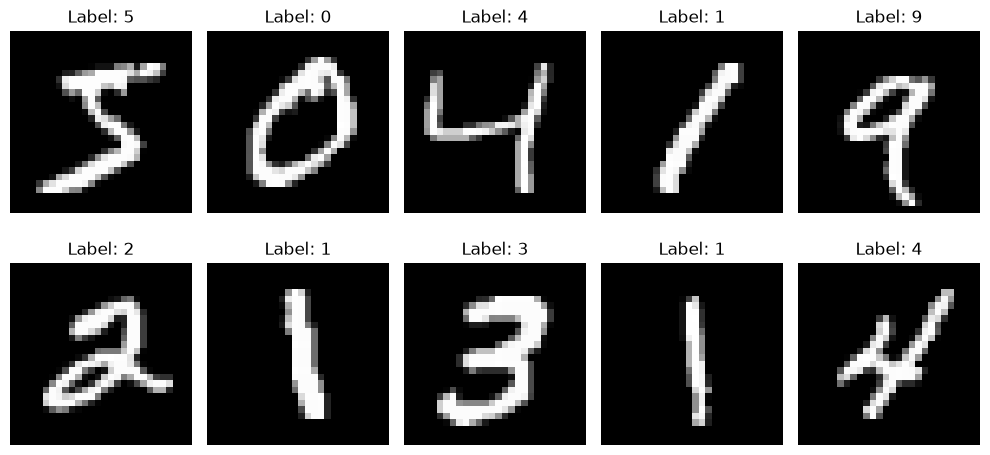

In [3]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # Convolution layer
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),

    # Reduce image size
    MaxPooling2D((2, 2)),

    # Second convolution layer
    Conv2D(64, (3, 3), activation="relu"),

    # Reduce size again
    MaxPooling2D((2, 2)),

    # Convert 2D features into 1D
    Flatten(),

    # Fully connected layer
    Dense(128, activation="relu"),

    # Prevent overfitting
    Dropout(0.5),

    # Output: 10 digits (0-9)
    Dense(10, activation="softmax")
])

model.summary()

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.9207 - loss: 0.2579 - val_accuracy: 0.9840 - val_loss: 0.0559
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9734 - loss: 0.0897 - val_accuracy: 0.9883 - val_loss: 0.0379
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9799 - loss: 0.0652 - val_accuracy: 0.9907 - val_loss: 0.0363
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9836 - loss: 0.0545 - val_accuracy: 0.9892 - val_loss: 0.0391
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9859 - loss: 0.0473 - val_accuracy: 0.9918 - val_loss: 0.0331


In [8]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9901 - loss: 0.0274
Test Loss: 0.027364330366253853
Test Accuracy: 0.9901000261306763
Test Accuracy (%): 99.01000261306763


In [9]:
predictions = model.predict(X_test)

print("Prediction shape:", predictions.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Prediction shape: (10000, 10)


In [15]:
predicted_labels = np.argmax(predictions, axis=1)

print("First 20 predicted digits:")
print(predicted_labels[:20])

print("\nFirst 20 actual digits:")
print(y_test[:20])

First 20 predicted digits:
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]

First 20 actual digits:
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


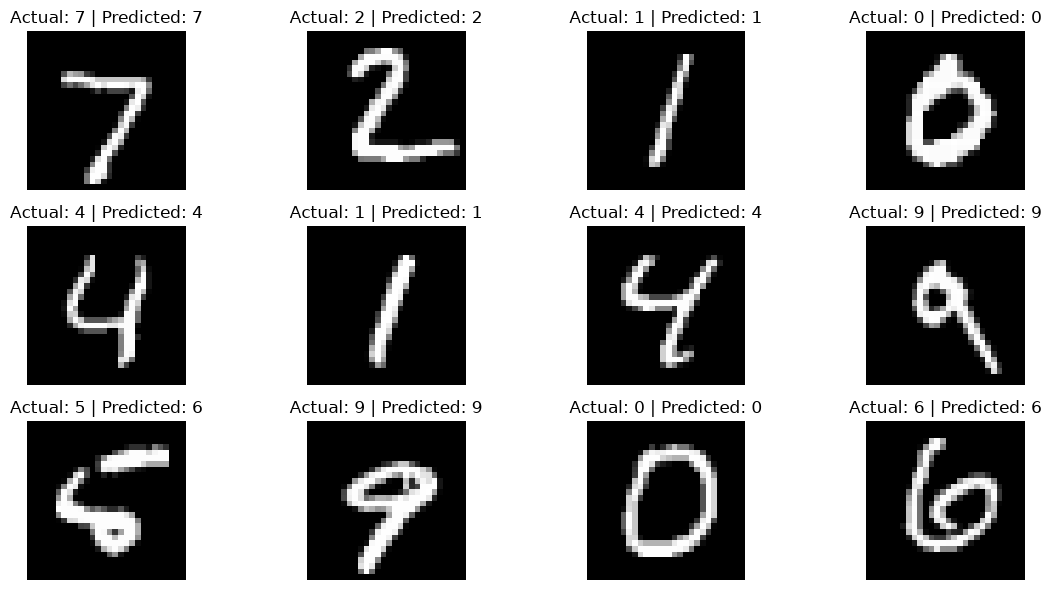

In [11]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Actual: {y_test[i]} | Predicted: {predicted_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

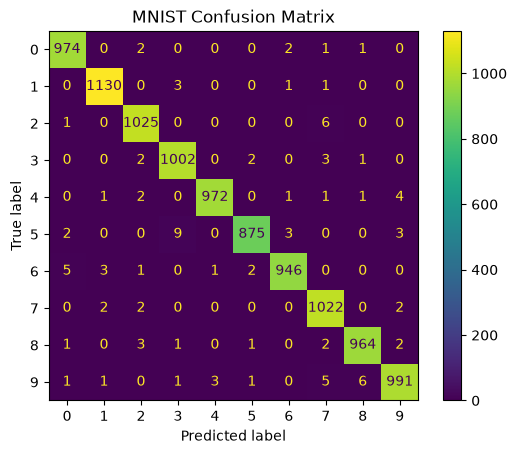

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot()
plt.title("MNIST Confusion Matrix")
plt.show()

In [13]:
incorrect = np.where(predicted_labels != y_test)[0]

print("Number of incorrect predictions:", len(incorrect))
print("Number of correct predictions:", len(y_test) - len(incorrect))

Number of incorrect predictions: 99
Number of correct predictions: 9901


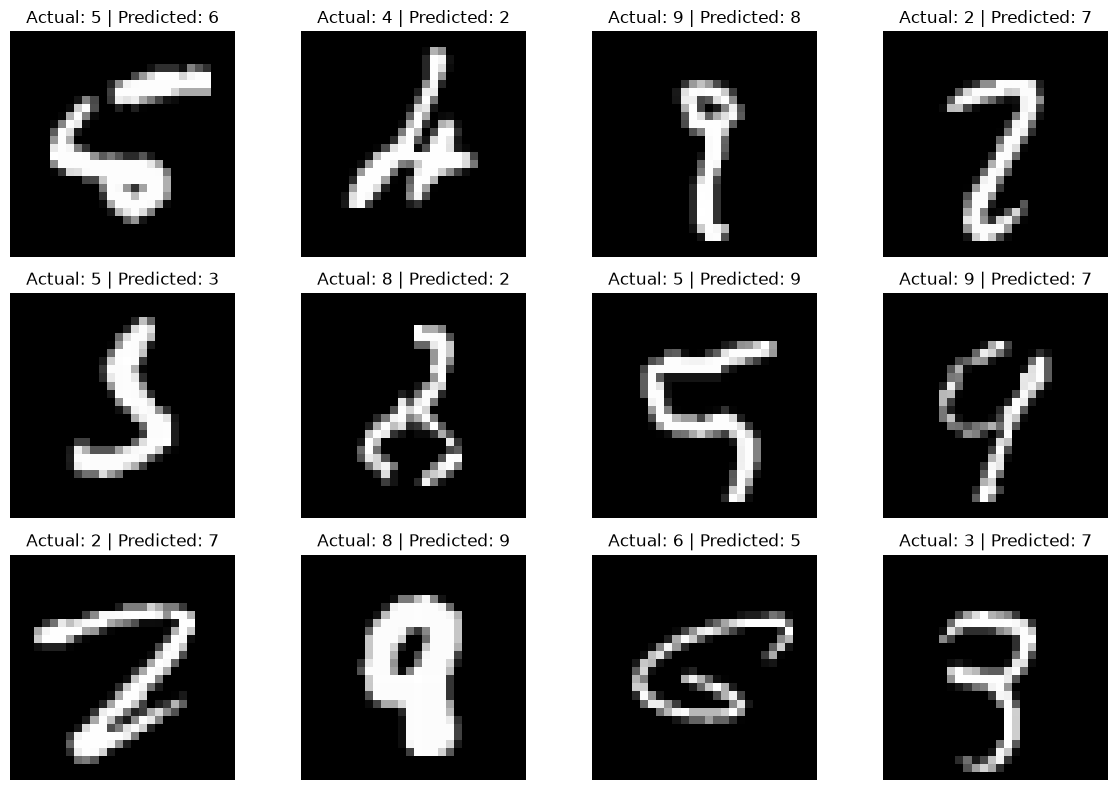

In [14]:
plt.figure(figsize=(12, 8))

for i in range(12):
    index = incorrect[i]

    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[index].reshape(28, 28), cmap="gray")
    plt.title(
        f"Actual: {y_test[index]} | Predicted: {predicted_labels[index]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

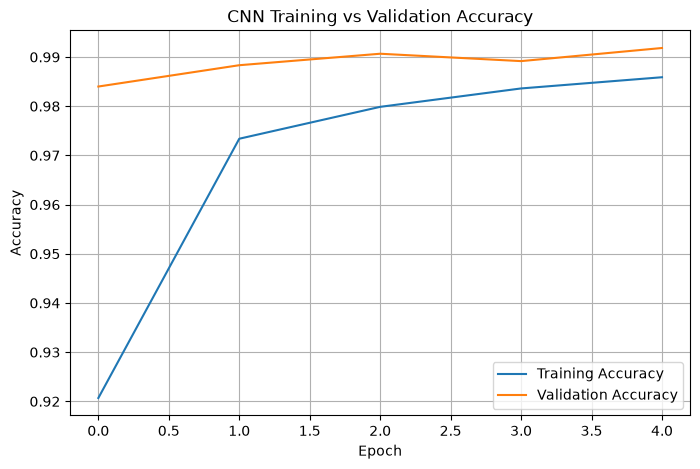

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

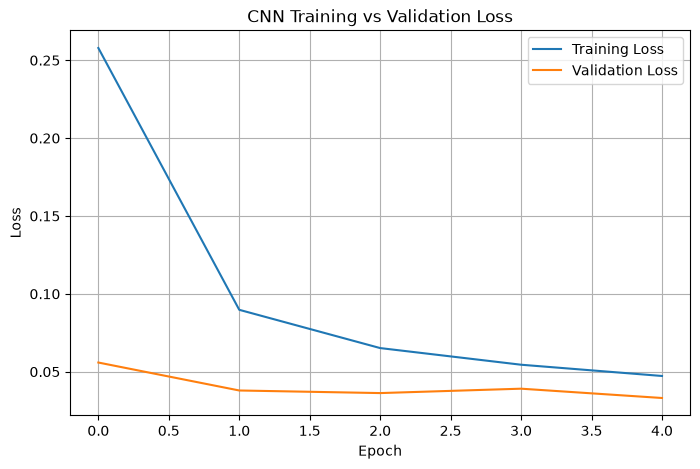

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [3]:
# Step 16 - Load data, train CNN and save model

import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize images
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(10, activation="softmax")
])

# Compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

# Save model
model.save("mnist_cnn_model.keras")

print("Model saved successfully!")

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9235 - loss: 0.2514 - val_accuracy: 0.9805 - val_loss: 0.0677
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9738 - loss: 0.0892 - val_accuracy: 0.9888 - val_loss: 0.0406
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9814 - loss: 0.0649 - val_accuracy: 0.9892 - val_loss: 0.0348
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9842 - loss: 0.0540 - val_accuracy: 0.9908 - val_loss: 0.0364
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9870 - loss: 0.0441 - val_accuracy: 0.9903 - val_loss: 0.0301
Model saved successfully!


In [4]:
from tensorflow.keras.models import load_model

loaded_model = load_model("mnist_cnn_model.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [5]:
loss, accuracy = loaded_model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy * 100, "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9908 - loss: 0.0266
Test Accuracy: 99.08000230789185 %


In [6]:
index = 0

image = X_test[index].reshape(1, 28, 28, 1)

prediction = loaded_model.predict(image)
predicted_digit = np.argmax(prediction)

print("Actual digit:", y_test[index])
print("Predicted digit:", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Actual digit: 7
Predicted digit: 7


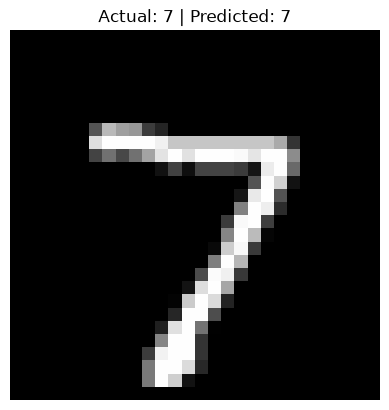

In [8]:
import matplotlib.pyplot as plt
plt.imshow(X_test[index].reshape(28, 28), cmap="gray")
plt.title(f"Actual: {y_test[index]} | Predicted: {predicted_digit}")
plt.axis("off")
plt.show()

In [11]:
from sklearn.metrics import classification_report

predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

print(classification_report(y_test, predicted_labels))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



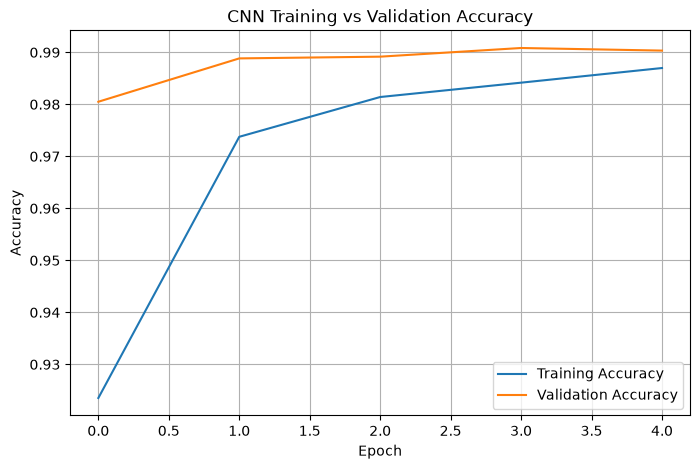

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("training_accuracy.png")
plt.show()

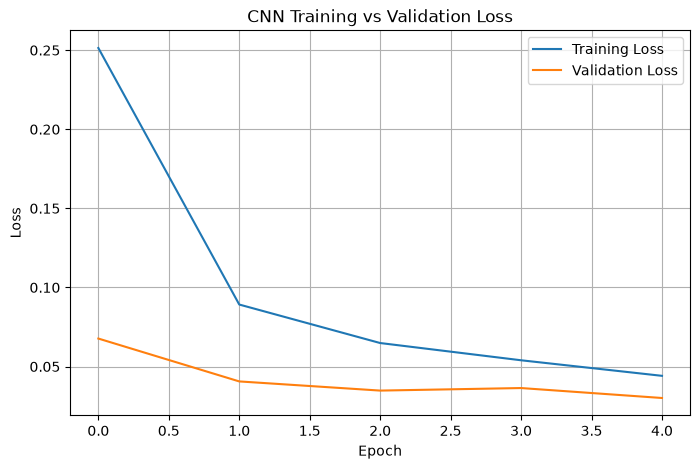

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig("training_loss.png")
plt.show()

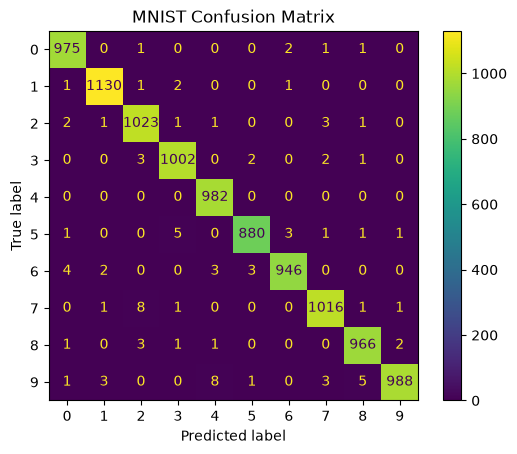

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot()
plt.title("MNIST Confusion Matrix")

plt.savefig("confusion_matrix.png")
plt.show()

# Dataset       : MNIST
# Model         : CNN
# Training Data : 60,000 images
# Testing Data  : 10,000 images
# Epochs        : 5
# Test Accuracy : 99.01%
# Correct       : 9,901
# Incorrect     : 99
